# Sales Forecasting Baseline Notebook

This notebook defines a **simple, reproducible baseline** for later model comparison:

- Model: `seasonal_naive_365` (predict each day from the value 365 days earlier)
- Validation: same 548-day rolling windows used in the main pipeline
- Output: `submissions/submission_baseline_notebook.csv`


## 1. Setup


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Resolve project root whether notebook is launched from repo root or notebooks/
_cwd = Path.cwd().resolve()
if (_cwd / "data").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise FileNotFoundError("Could not resolve project root containing data/.")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUT_DIR = PROJECT_ROOT / "submissions"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "sales.csv"
TEST_TEMPLATE_FILE = DATA_DIR / "sample_submission.csv"
OUT_FILE = OUT_DIR / "submission_baseline_notebook.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_FILE:   {TRAIN_FILE}")
print(f"TEST_FILE:    {TEST_TEMPLATE_FILE}")
print(f"OUT_FILE:     {OUT_FILE}")

PROJECT_ROOT: E:\Temp\datathon_2026
TRAIN_FILE:   E:\Temp\datathon_2026\data\raw\sales.csv
TEST_FILE:    E:\Temp\datathon_2026\data\raw\sample_submission.csv
OUT_FILE:     E:\Temp\datathon_2026\submissions\submission_baseline_notebook.csv


## 2. Load Data


In [2]:
sales = pd.read_csv(TRAIN_FILE, parse_dates=["Date"]).sort_values("Date")
sample_sub = pd.read_csv(TEST_TEMPLATE_FILE, parse_dates=["Date"]).sort_values("Date")

print(f"Sales shape: {sales.shape}")
print(f"Sales date range: {sales['Date'].min().date()} -> {sales['Date'].max().date()}")
print(f"Submission template shape: {sample_sub.shape}")
print(f"Submission horizon: {sample_sub['Date'].min().date()} -> {sample_sub['Date'].max().date()}")

sales.head()

Sales shape: (3833, 3)
Sales date range: 2012-07-04 -> 2022-12-31
Submission template shape: (548, 3)
Submission horizon: 2023-01-01 -> 2024-07-01


,Date,Revenue,COGS
0,2012-07-04,"5,123,547.940","3,982,991.190"
1,2012-07-05,"2,751,773.450","2,150,580.230"
2,2012-07-06,"3,054,029.420","2,517,632.840"
3,2012-07-07,"2,667,930.940","2,108,246.620"
4,2012-07-08,"2,360,851.900","1,808,622.790"


## 3. Baseline Functions


In [3]:
DEFAULT_HORIZON_DAYS = 548
DEFAULT_TUNE_CUTOFFS = ["2018-06-30", "2019-06-30", "2020-06-30", "2021-06-30"]


def seasonal_naive_forecast(history: pd.Series, future_dates: pd.Series, lag_days: int = 365) -> pd.Series:
    hist = history.copy()
    hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()

    future_ds = pd.to_datetime(pd.Series(future_dates)).sort_values()
    preds = {}
    for d in future_ds:
        lag_date = d - pd.Timedelta(days=lag_days)
        lag_val = hist.get(lag_date, np.nan)
        if np.isnan(lag_val):
            lag_val = float(hist.iloc[-1])
        preds[d] = float(lag_val)
    return pd.Series(preds).sort_index()


def metrics_row(y_true: pd.Series, y_pred: pd.Series, target: str, fold: str) -> dict:
    err = y_pred.values - y_true.values
    abs_err = np.abs(err)

    def seg_mae(start: int, end: int | None) -> float:
        seg = abs_err[start:end]
        return float(seg.mean()) if len(seg) else np.nan

    return {
        "target": target,
        "fold": fold,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_pred_minus_true": float(err.mean()),
        "MAE_1_180": seg_mae(0, 180),
        "MAE_181_365": seg_mae(180, 365),
        "MAE_366_548": seg_mae(365, None),
    }


def run_backtest(df: pd.DataFrame, target_col: str, cutoffs: list[str], horizon_days: int = 548) -> pd.DataFrame:
    out = []
    work = df[["Date", target_col]].copy().sort_values("Date")

    for cutoff_str in cutoffs:
        cutoff = pd.Timestamp(cutoff_str)
        train_df = work[work["Date"] <= cutoff].copy()
        valid_df = work[(work["Date"] > cutoff) & (work["Date"] <= cutoff + pd.Timedelta(days=horizon_days))].copy()
        if len(train_df) < 730 or len(valid_df) < min(365, horizon_days):
            continue

        hist = pd.Series(train_df[target_col].values, index=train_df["Date"])
        pred = seasonal_naive_forecast(hist, valid_df["Date"], lag_days=365)
        y_valid = pd.Series(valid_df[target_col].values, index=valid_df["Date"])
        out.append(metrics_row(y_valid, pred, target_col, cutoff_str))

    return pd.DataFrame(out)


## 4. Backtest (548-day, rolling cutoffs)


In [4]:
rev_bt = run_backtest(sales, "Revenue", DEFAULT_TUNE_CUTOFFS, DEFAULT_HORIZON_DAYS)
cogs_bt = run_backtest(sales, "COGS", DEFAULT_TUNE_CUTOFFS, DEFAULT_HORIZON_DAYS)

backtest_detail = pd.concat([rev_bt, cogs_bt], ignore_index=True)
backtest_summary = backtest_detail.groupby("target")[["MAE", "RMSE", "R2", "bias_pred_minus_true", "MAE_1_180", "MAE_181_365", "MAE_366_548"]].mean().reset_index()

print("Fold-level detail:")
display(backtest_detail)
print("\nMean summary:")
display(backtest_summary)


Fold-level detail:


,target,fold,MAE,RMSE,R2,bias_pred_minus_true,MAE_1_180,MAE_181_365,MAE_366_548
0,Revenue,2018-06-30,"3,836,734.884","4,936,931.115",-5.456,"3,387,887.517","1,401,835.947","2,465,596.246","7,617,841.206"
1,Revenue,2019-06-30,"1,714,024.121","2,193,281.271",-1.177,"1,527,379.669","1,630,878.833","867,853.947","2,651,224.307"
2,Revenue,2020-06-30,"1,546,112.798","2,125,124.480",-0.869,"1,019,518.749","647,246.522","695,649.546","3,290,001.495"
3,Revenue,2021-06-30,"1,404,517.423","1,859,470.555",-0.429,"794,651.737","705,958.094","890,986.808","2,610,767.932"
4,COGS,2018-06-30,"3,510,677.761","4,687,755.123",-7.119,"3,334,030.466","1,041,803.891","2,012,238.662","7,453,893.772"
5,COGS,2019-06-30,"1,475,563.492","1,886,463.589",-1.058,"1,332,085.132","1,094,029.644","734,168.023","2,600,340.837"
6,COGS,2020-06-30,"1,460,167.347","2,084,565.036",-1.401,"1,107,355.248","502,885.721","584,035.459","3,287,462.931"
7,COGS,2021-06-30,"1,321,835.184","1,793,291.892",-0.711,"710,981.020","494,120.507","779,715.148","2,684,025.614"



Mean summary:


,target,MAE,RMSE,R2,bias_pred_minus_true,MAE_1_180,MAE_181_365,MAE_366_548
0,COGS,"1,942,060.946","2,613,018.910",-2.572,"1,621,112.966","783,209.941","1,027,539.323","4,006,430.789"
1,Revenue,"2,125,347.307","2,778,701.855",-1.983,"1,682,359.418","1,096,479.849","1,230,021.637","4,042,458.735"


## 5. Visual Check (Latest Fold, Revenue)


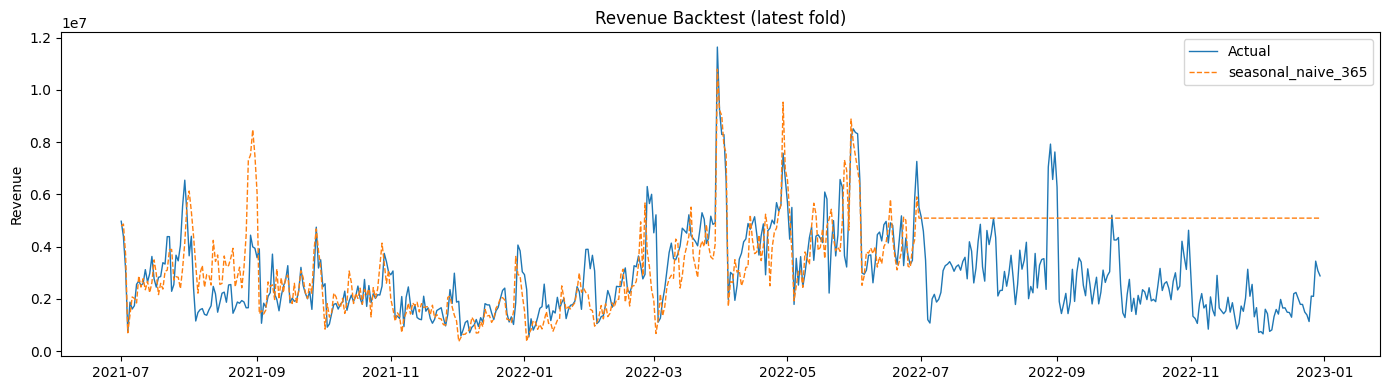

In [5]:
latest_cutoff = pd.Timestamp(DEFAULT_TUNE_CUTOFFS[-1])
latest_train = sales[sales["Date"] <= latest_cutoff].copy()
latest_valid = sales[(sales["Date"] > latest_cutoff) & (sales["Date"] <= latest_cutoff + pd.Timedelta(days=DEFAULT_HORIZON_DAYS))].copy()

hist = pd.Series(latest_train["Revenue"].values, index=latest_train["Date"])
pred = seasonal_naive_forecast(hist, latest_valid["Date"], lag_days=365)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(latest_valid["Date"], latest_valid["Revenue"], label="Actual", lw=1.0)
ax.plot(pred.index, pred.values, label="seasonal_naive_365", lw=1.0, linestyle="--")
ax.set_title("Revenue Backtest (latest fold)")
ax.set_ylabel("Revenue")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Train-on-full and Create Baseline Submission


In [6]:
future_dates = sample_sub["Date"].copy()

rev_hist_full = pd.Series(sales["Revenue"].values, index=sales["Date"])
cogs_hist_full = pd.Series(sales["COGS"].values, index=sales["Date"])

rev_pred_test = seasonal_naive_forecast(rev_hist_full, future_dates, lag_days=365)
cogs_pred_test = seasonal_naive_forecast(cogs_hist_full, future_dates, lag_days=365)

submission = pd.DataFrame({
    "Date": future_dates.dt.strftime("%Y-%m-%d"),
    "Revenue": rev_pred_test.values,
    "COGS": cogs_pred_test.values,
})
submission.to_csv(OUT_FILE, index=False)

print(f"Saved baseline submission: {OUT_FILE}")
print(f"Rows: {len(submission)} | Nulls: {submission.isna().sum().sum()}")
submission.head()

Saved baseline submission: E:\Temp\datathon_2026\submissions\submission_baseline_notebook.csv
Rows: 548 | Nulls: 0


,Date,Revenue,COGS
0,2023-01-01,"2,932,155.470","3,019,583.500"
1,2023-01-02,"2,361,965.000","2,368,851.110"
2,2023-01-03,"545,563.720","476,501.310"
3,2023-01-04,"1,242,319.380","1,057,834.070"
4,2023-01-05,"809,977.600","684,605.300"


## 7. Optional: Compare with Current Hybrid Report


In [7]:
hybrid_report = PROJECT_ROOT / "reports" / "forecasting" / "validation" / "model_holdout_summary.csv"
if hybrid_report.exists():
    rep = pd.read_csv(hybrid_report)
    rev_rows = rep[(rep["target"] == "Revenue") & (rep["model"].isin(["pass_2_hybrid_regime_lgbm", "seasonal_naive_365"]))]
    display(rev_rows[["model", "MAE", "RMSE", "bias_pred_minus_true", "MAE_1_180", "MAE_181_365", "MAE_366_548"]])
else:
    print(f"Report not found: {hybrid_report}")

,model,MAE,RMSE,bias_pred_minus_true,MAE_1_180,MAE_181_365,MAE_366_548
0,pass_2_hybrid_regime_lgbm,"637,477.659","898,048.384","-83,591.714","588,728.900","777,449.285","543,925.888"
7,seasonal_naive_365,"1,404,517.423","1,859,470.555","794,651.737","705,958.094","890,986.808","2,610,767.932"
